In [1]:
# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Time series model
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

In [8]:
!pip install yfinance pytrends pandas numpy matplotlib seaborn statsmodels yfinance

In [10]:
import pandas as pd
tesco = pd.read_csv("/content/tesco_cleaned.csv")
greggs = pd.read_csv("/content/greggs_cleaned.csv")

tesco.head()

,Date,Close,High,Low,Open,Volume,Return,Log_Return,MA_4,Volatility,Return_Zscore,Return_MinMax
0,2024-04-01,289.384003,298.177427,286.486172,296.378782,66824928,-0.023601,-0.023884,291.782188,0.019457,-0.996000,0.442840
1,2024-04-08,282.688934,305.871638,278.143347,289.383948,157580485,-0.023136,-0.023407,290.608055,0.023269,-0.979839,0.445292
2,2024-04-15,281.190033,286.785861,277.292949,283.888031,110627443,-0.005302,-0.005316,287.410431,0.015335,-0.360213,0.539304
3,2024-04-22,288.684448,296.178853,285.087128,285.087128,115358426,0.026652,0.026304,285.486855,0.023591,0.750072,0.707762
4,2024-04-29,298.077423,302.034490,286.885798,289.383933,76241655,0.032537,0.032019,287.660210,0.026432,0.954538,0.738784


In [12]:
features = ['Open','High','Low','Volume']
target = 'Close'

X = tesco[features]
y = tesco[target]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

In [18]:
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression Results
MAE: 5.829562005924818
RMSE: 10.083331770070048
R2: 0.9655529340532838


In [19]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [20]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Results
MAE: 8.152955539521722
RMSE: 13.410351641989232
R2: 0.9390709432982265


In [21]:
tesco['Date'] = pd.to_datetime(tesco['Date'])
tesco.set_index('Date', inplace=True)

ts_data = tesco['Close']

In [22]:
arima_model = ARIMA(ts_data, order=(5,1,0))

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  101
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -384.216
Date:                Tue, 10 Mar 2026   AIC                            780.433
Time:                        17:28:55   BIC                            796.064
Sample:                    04-01-2024   HQIC                           786.759
                         - 03-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0372      0.094      0.397      0.691      -0.146       0.221
ar.L2          0.0166      0.115      0.144      0.886      -0.210       0.243
ar.L3         -0.0549      0.095     -0.576      0.5

In [23]:
forecast = arima_result.forecast(steps=10)

print("ARIMA Forecast")
print(forecast)

ARIMA Forecast
2026-03-09    467.360444
2026-03-16    460.353129
2026-03-23    459.075619
2026-03-30    462.048332
2026-04-06    463.946884
2026-04-13    465.317167
2026-04-20    466.658174
2026-04-27    466.910198
2026-05-04    466.273828
2026-05-11    465.803389
Freq: W-MON, Name: predicted_mean, dtype: float64


In [24]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5.829562,10.083332,0.965553
1,Random Forest,8.152956,13.410352,0.939071


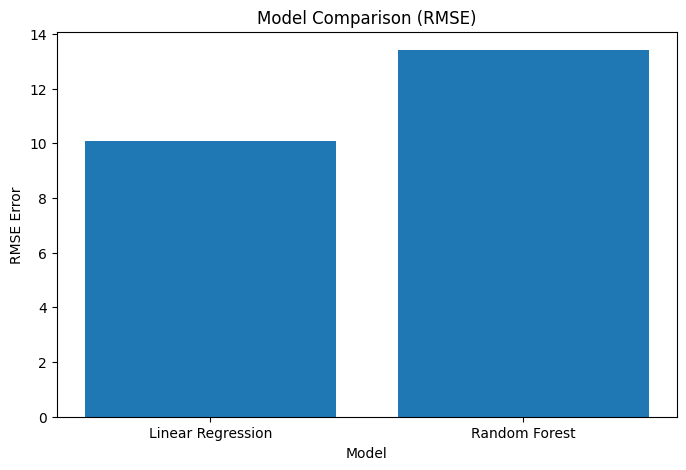

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.bar(comparison['Model'], comparison['RMSE'])

plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE Error")
plt.xlabel("Model")

plt.show()

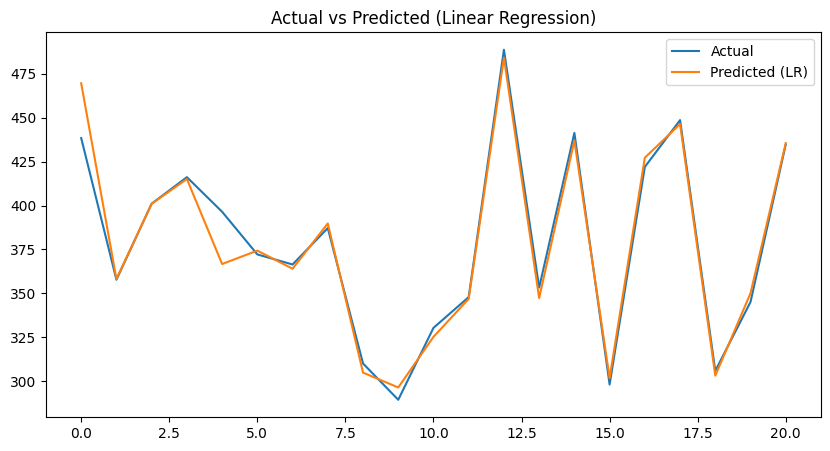

In [28]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual")
plt.plot(lr_predictions, label="Predicted (LR)")

plt.legend()
plt.title("Actual vs Predicted (Linear Regression)")

plt.show()